In [3]:
import pandas as pd

In [4]:
data = pd.read_csv("Customer-Churn-Records.csv")

In [5]:
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


### Датасет на 10000 строк и 18 колонок

In [7]:
data.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

### Датасет чист, пробелов нету

In [9]:
data.duplicated().sum()

np.int64(0)

### В датасете нету дубликатов

In [11]:
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [12]:
import matplotlib.pyplot as plt

In [13]:
num_cols = [
    'CreditScore','Age','Tenure','Balance',
    'NumOfProducts','EstimatedSalary',
    'Point Earned','Satisfaction Score'
]

cat_cols = [
    'Geography','Gender','HasCrCard',
    'IsActiveMember','Card Type',
    'Complain','Exited'
]


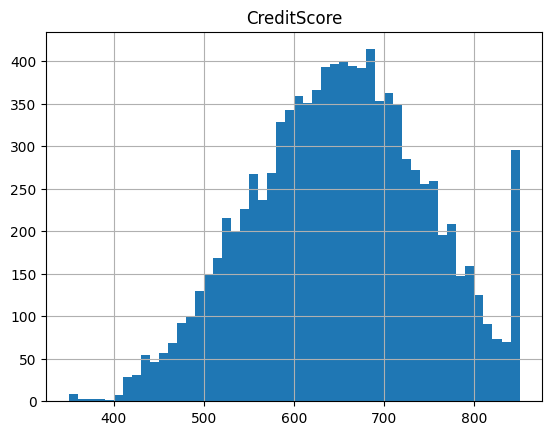

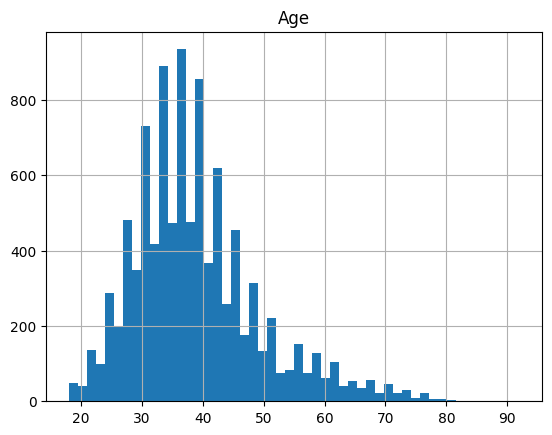

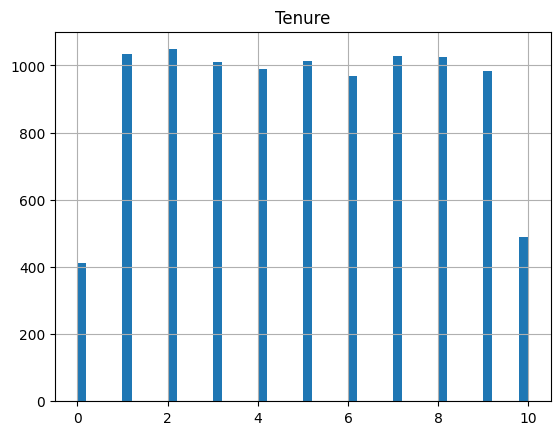

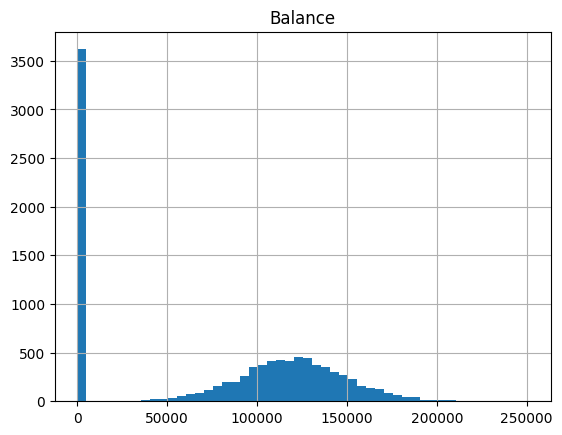

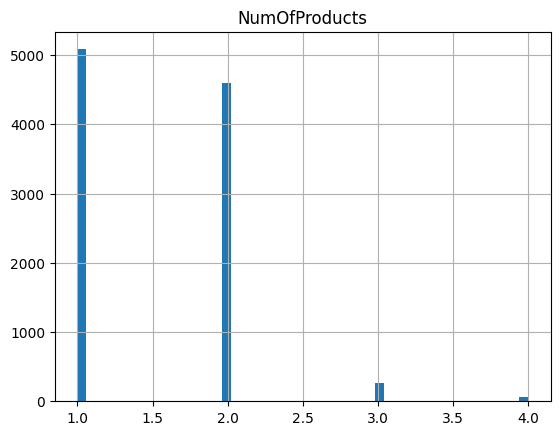

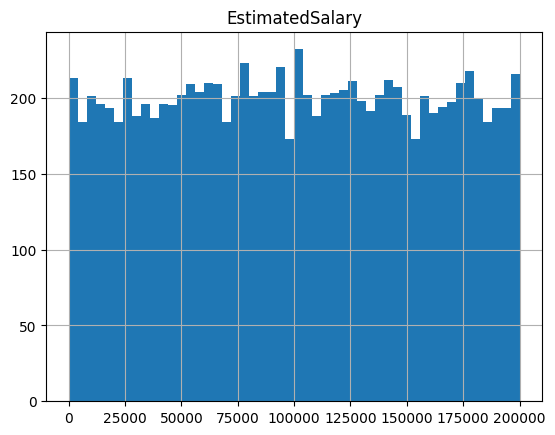

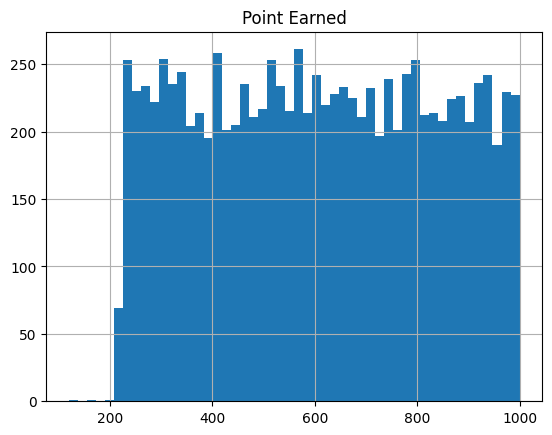

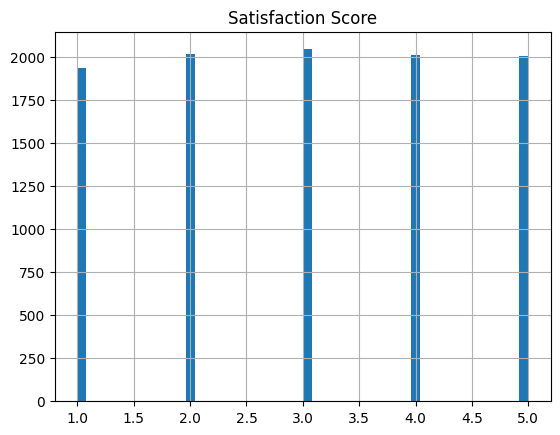

In [14]:
for col in num_cols:
    data[col].hist(bins=50)
    plt.title(col)
    plt.show()


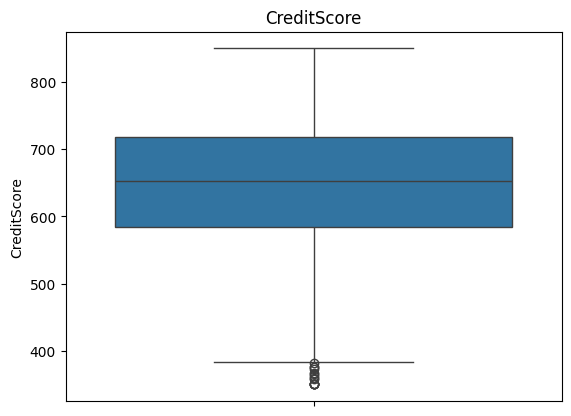

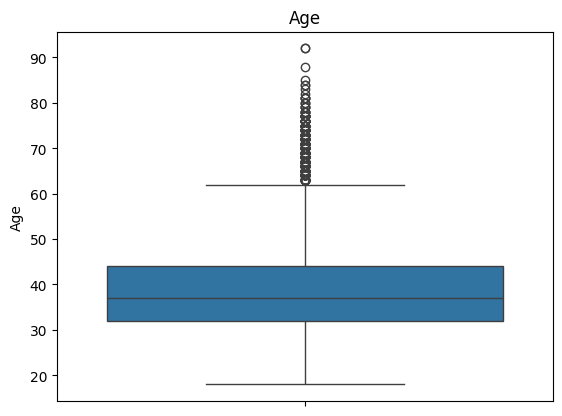

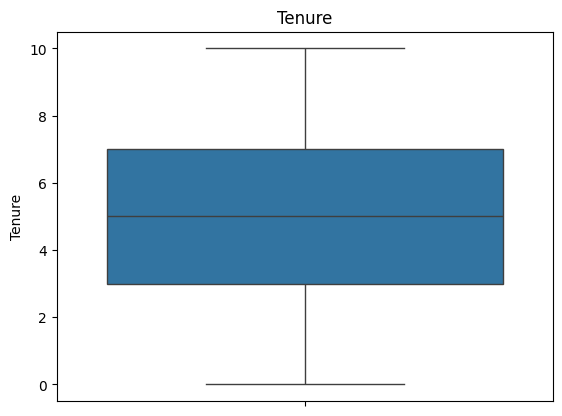

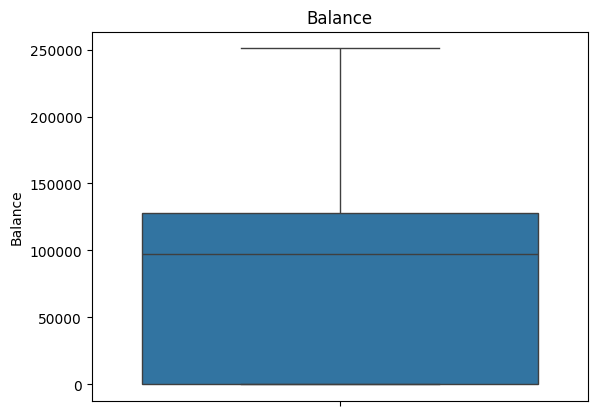

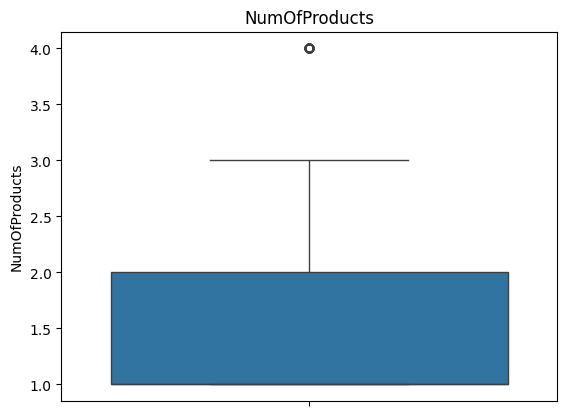

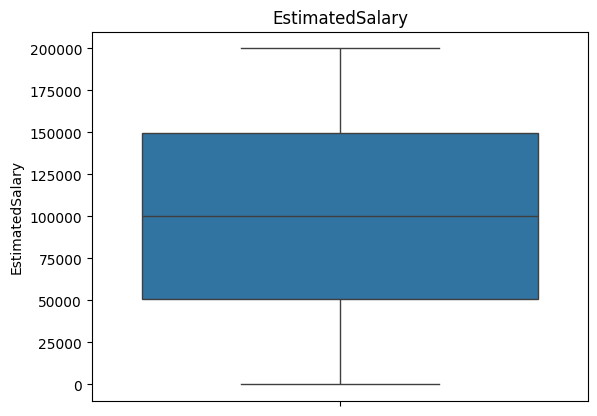

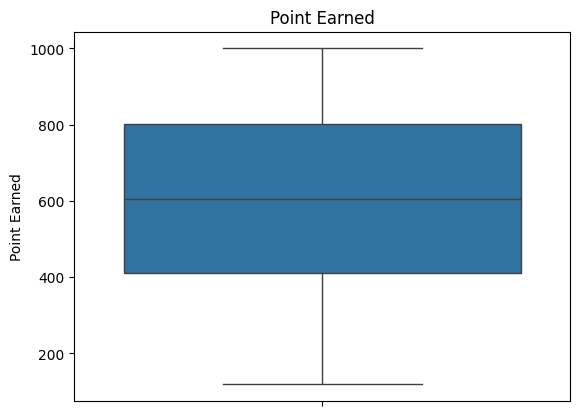

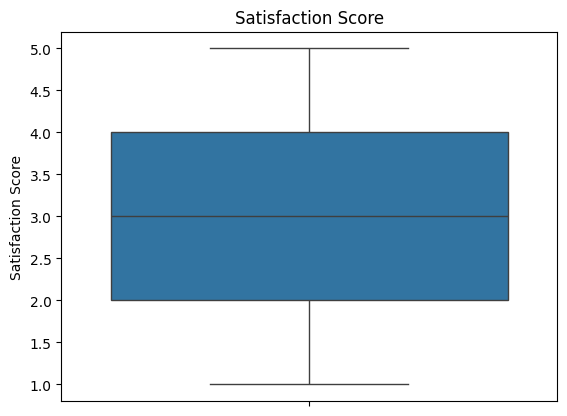

In [15]:
import seaborn as sns

for col in num_cols:
    sns.boxplot(y=data[col])
    plt.title(col)
    plt.show()


In [17]:
corr_pearson = data[num_cols].corr(method='pearson')

corr_spearman = data[num_cols].corr(method='spearman')

<Axes: >

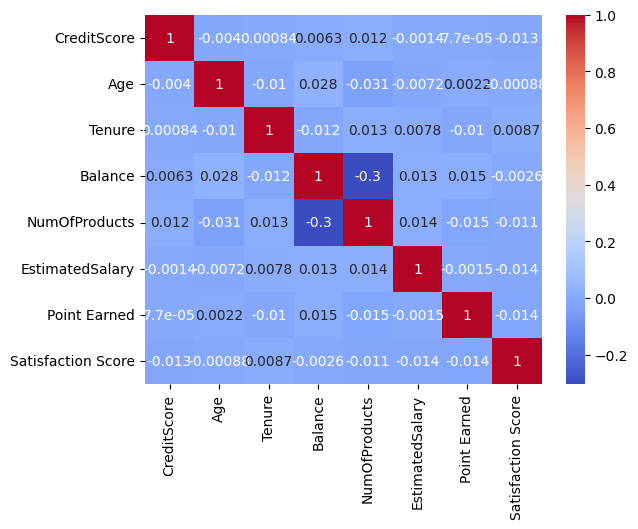

In [18]:
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm')


In [19]:
data[num_cols + ['Exited']].corr()['Exited'].sort_values(ascending=False)


Exited                1.000000
Age                   0.285296
Balance               0.118577
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
Tenure               -0.013656
CreditScore          -0.026771
NumOfProducts        -0.047611
Name: Exited, dtype: float64

In [20]:
pd.crosstab(data['Card Type'], data['Exited'], normalize='index')


Exited,0,1
Card Type,,
DIAMOND,0.782210,0.217790
GOLD,0.807354,0.192646
PLATINUM,0.796393,0.203607
SILVER,0.798878,0.201122


In [21]:
pd.crosstab(data['Gender'], data['Exited'], normalize='index')

Exited,0,1
Gender,,
Female,0.749285,0.250715
Male,0.835257,0.164743


In [22]:
pd.crosstab(data['Geography'], data['Exited'], normalize='index')

Exited,0,1
Geography,,
France,0.838253,0.161747
Germany,0.675568,0.324432
Spain,0.833266,0.166734


<Axes: xlabel='Geography', ylabel='count'>

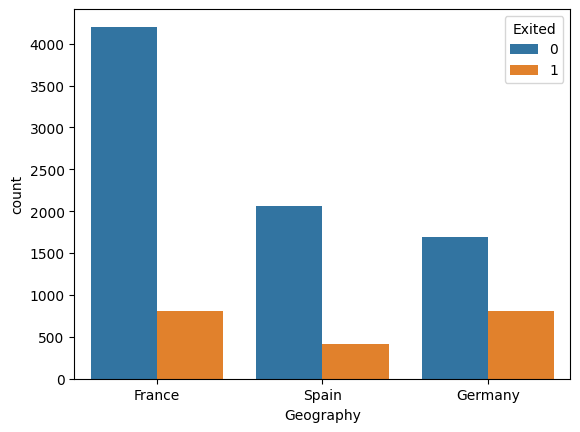

In [23]:
sns.countplot(x='Geography', hue='Exited', data=data)


In [24]:
data['AgeGroup'] = pd.cut(data['Age'], bins=[18,30,40,50,60,80])
pd.crosstab(data['AgeGroup'], data['Exited'], normalize='index')


Exited,0,1
AgeGroup,,
"(18, 30]",0.924974,0.075026
"(30, 40]",0.878904,0.121096
"(40, 50]",0.660345,0.339655
"(50, 60]",0.437892,0.562108
"(60, 80]",0.747788,0.252212


<Axes: xlabel='Exited', ylabel='Age'>

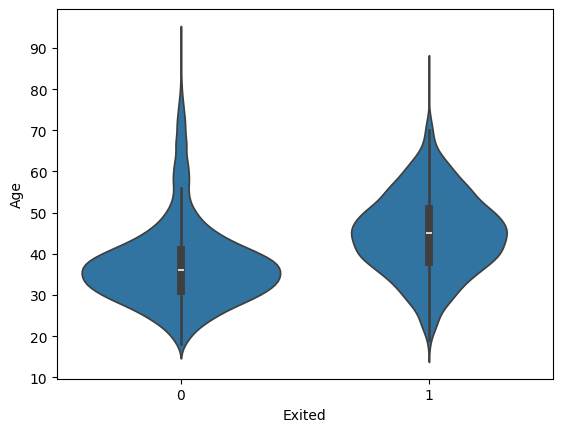

In [30]:
sns.violinplot(x='Exited', y='Age', data=data)


## Гипотеза 1: Клиенты в возрастной группе 50–60 лет имеют более высокий риск оттока (Exited=1) по сравнению с другими возрастными группами.

In [33]:
data['AgeGroup'] = pd.cut(data['Age'], bins=[18,30,40,50,60,80])

age_churn = pd.crosstab(data['AgeGroup'], data['Exited'], normalize='index')
age_churn


Exited,0,1
AgeGroup,,
"(18, 30]",0.924974,0.075026
"(30, 40]",0.878904,0.121096
"(40, 50]",0.660345,0.339655
"(50, 60]",0.437892,0.562108
"(60, 80]",0.747788,0.252212


<Axes: xlabel='Exited', ylabel='AgeGroup'>

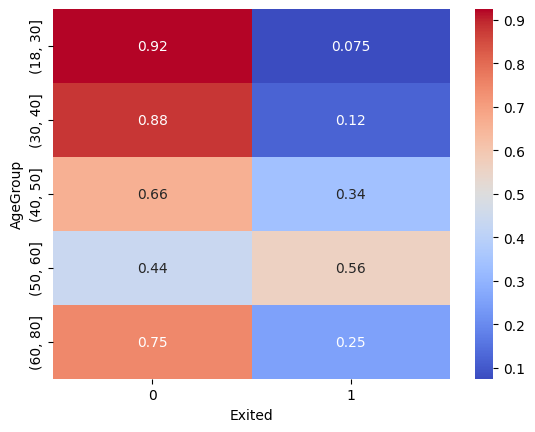

In [34]:
import seaborn as sns
sns.heatmap(age_churn, annot=True, cmap='coolwarm')


### В возрастной группе 50-60 лет 56.2% клиентов ушли, что значительно выше, чем у других групп.
### Гипотеза подтверждается: 50-60 лет сегмент повышенного риска оттока.


## Гипотеза 2: Клиенты из Германии имеют более высокий риск оттока по сравнению с клиентами из Франции и Испании.

<Axes: xlabel='Exited', ylabel='Geography'>

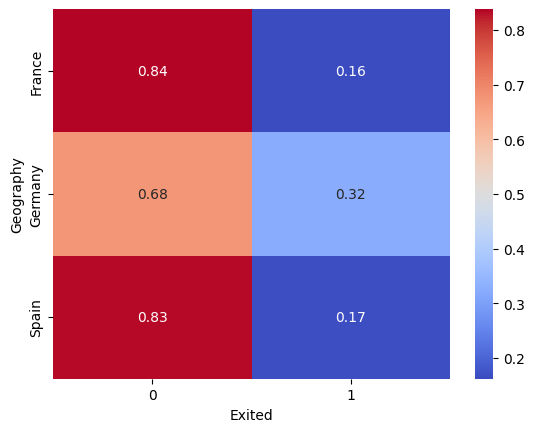

In [37]:
geo_churn = pd.crosstab(data['Geography'], data['Exited'], normalize='index')
geo_churn
sns.heatmap(geo_churn, annot=True, cmap='coolwarm')


### У Германии 32.4% ушедших, во Франции и Испании -16%.
### Гипотеза подтверждается: география явно влияет на отток.